# Air Pollution and Health Outcomes
## Course Project - CS A1160 Beginner's Python for Engineers
### Team members and Roles (TODO!: Add roles):
- Lishchuk Oleksii 
- Purnama Teodorus
- Yisunsri Napat

## Overview
This project analyzes the relationship between air pollution levels and health outcomes.
### Goal
Investigate the association of pollution levels with:
- Life expectancy
- Cardiovascular disease deaths
### Data Sources
The following datasets are used due to their quality of reporting, quantity of data, and completeness.
- Main Dataset: WHO Ambient Air Quality Database (Update Jan 2024)</br>
Measurements of annual mean concentrations of nitrogen dioxide (NO2), particulate matter of a diameter equal or smaller than 10 μm (PM10) or equal or smaller than 2.5 μm (PM2.5) (World Health Organization, 2024).
- Additional Dataset: City Health Dashboard</br>
Life expectancy and cardiovascular disease deaths of American cities (Department of Population Health, NYU Langone Health 2026)

## Project Structure
This notebook follows the structure:
1. Libraries
2. Helper functions
3. Data reading
4. Data cleaning
5. Data merging
6. Statistics calculation
7. Plotting
8. Results interpretation

## Libraries
This project uses the following libraries to process the datasets.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

MAIN_FILE="main.xlsx"
ADDITIONAL_FILE="additional.csv"
SHEET_NAME="Update 2024 (V6.1)"

## Helper Functions


In [2]:
def clean_main_city_name(city_name): #Cleans inconsistent naming
    if pd.isna(city_name):
        return np.nan
    city_name=str(city_name)
    city_name=city_name.split("/")[0]
    city_name=re.sub(r"\s+[A-Z]{2}$","",city_name)
    return city_name.strip()

def annotate_all_points(df,x_col,y_col,label_col): # to annotate cities on first plots
    for i,row in df.iterrows():
        plt.annotate(row[label_col],(row[x_col],row[y_col]),fontsize=8)

def station_group(station_type): # for clarity of these freaking regions i officially hate that column and plot with it i hate it
    if pd.isna(station_type):
        return np.nan
    station_type=str(station_type).lower()
    if "suburban" in station_type:
        return "Suburban"
    if "urban" in station_type:
        return "Urban"
    if "rural" in station_type:
        return "Rural"
    return np.nan

def add_trendline(x,y):
    x=pd.Series(x).astype(float)
    y=pd.Series(y).astype(float)
    valid=pd.concat([x,y],axis=1).dropna()
    slope,intercept,i,j,k_=stats.linregress(valid.iloc[:,0],valid.iloc[:,1])
    x_line=np.linspace(valid.iloc[:,0].min(),valid.iloc[:,0].max(),200)
    y_line=slope*x_line+intercept
    plt.plot(x_line,y_line,color="red",label="Trendline")

def pearson_r(x,y):
    x=pd.Series(x).astype(float)
    y=pd.Series(y).astype(float)
    valid=pd.concat([x,y],axis=1).dropna()
    return stats.pearsonr(valid.iloc[:,0],valid.iloc[:,1])[0]

def scipy_skew(series):
    series=pd.Series(series).dropna()
    return stats.skew(series,bias=False)

def zscore_series(series):
    series=pd.Series(series).astype(float)
    return pd.Series(stats.zscore(series,nan_policy="omit"),index=series.index)

def summarize_with_ci(df,group_col,value_col,order):
    summary=df.groupby(group_col)[value_col].agg(["mean","std","count"]).reset_index()
    summary=summary[summary[group_col].isin(order)].copy()
    summary[group_col]=pd.Categorical(summary[group_col],categories=order,ordered=True)
    summary=summary.sort_values(group_col)
    summary["sem"]=summary["std"]/np.sqrt(summary["count"])
    summary["ci95"]=summary.apply(lambda row:stats.t.ppf(0.975,row["count"]-1)*row["sem"],axis=1)
    return summary

## Data Reading

In [3]:
main_raw=pd.read_excel(MAIN_FILE,sheet_name=SHEET_NAME)
additional_raw=pd.read_csv(ADDITIONAL_FILE)

## Data Cleaning
### Main Dataset
The main dataset includes data from various years and countries. This code filters the dataset to only include data from the United States in the year 2020, to make the data relevant to the additional dataset. The code also changes the name of the city to be consistent with the additional dataset. The columns that are used in the dataset and their contents are as follows:
- pm25_concentration = Annual mean concentration of particulate matter with diameter of 2.5μm or less (µg/m3)
- pm10_concentration = Annual mean concentration of particulate matter with diameter of 10 μm or less (µg/m3)
- no2_concentration = Annual mean concentration of nitrogen dioxide (µg/m3)
- population = Number of inhabitants
- latitude = Latitude of city
- longitude = Longitude of city
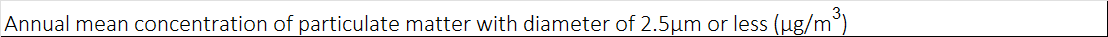

In [4]:
main_us_2020 = main_raw[(main_raw["country_name"]=="United States of America")&(main_raw["year"]==2020)].copy()

main_us_2020["city_clean"] = main_us_2020["city"].apply(clean_main_city_name)

city_air = main_us_2020.groupby("city_clean")[["pm25_concentration","pm10_concentration","no2_concentration","population","latitude","longitude"]].mean().reset_index()

city_air = city_air.rename(columns={"pm25_concentration":"pm25_mean","pm10_concentration":"pm10_mean","no2_concentration":"no2_mean"})

station_info = main_us_2020.groupby("city_clean")["type_of_stations"].first().reset_index()

city_air=city_air.merge(station_info,on="city_clean",how="left")

city_air["station_group"]=city_air["type_of_stations"].apply(station_group)

### Additional Dataset
The additional dataset is cleaned by only taking the "Total" row for each city. This code also makes sure that only non-duplicate cities are used. Finally, it formats the dataset so that it is ready to be merged. The used columns are as follows:
- geo_level = Level of geographical instance 
- group_name = Name of demographic represented
- geo_name = Name of the city
- metric_name = Name of metric
- est = Estimated value of the metric

In [5]:
health_total=additional_raw[(additional_raw["geo_level"]=="city")&(additional_raw["group_name"]=="Total")].copy()

health_total=health_total[["geo_name","metric_name","est"]]
health_total=health_total.drop_duplicates(subset=["geo_name","metric_name"])

health_city=health_total.pivot(index="geo_name",columns="metric_name",values="est").reset_index()
health_city.columns.name = None

health_city=health_city.rename(columns={"geo_name":"city_clean","Cardiovascular Disease Deaths":"cvd_deaths","Life Expectancy - City-Level":"life_expectancy"})

## Data merging
The cleaned main and additional datasets are merged into "analysis_df".

In [6]:
merged=city_air.merge(health_city,on="city_clean",how="inner")
analysis_df=merged.copy()

## Statistical Calculations
This part of the code calculates and presents some basic statistical properties of the dataset.

### Shape
The shape of the datasets shows the filtering process of the datasets.

In [7]:
print("MAIN RAW DATASET SHAPE:")
print(main_raw.shape)
print("\nMAIN US 2020 DATASET SHAPE:")
print(main_us_2020.shape)
print("\nCITY AIR DATASET SHAPE:")
print(city_air.shape)
print("\nHEALTH TOTAL DATASET SHAPE:")
print(health_total.shape)
print("\nHEALTH CITY DATASET SHAPE:")
print(health_city.shape)
print("\nMERGED DATASET SHAPE:")
print(merged.shape)
print("\nFINAL ANALYSIS DATASET SHAPE:")
print(analysis_df.shape)

#Store the name of relevant columns together for convenience
city_air_cols=["pm25_mean","pm10_mean","no2_mean","population","latitude","longitude"]
health_cols=["life_expectancy","cvd_deaths"]
merged_cols=["pm25_mean","pm10_mean","no2_mean","population","latitude","longitude","life_expectancy","cvd_deaths"]

MAIN RAW DATASET SHAPE:
(40098, 20)

MAIN US 2020 DATASET SHAPE:
(324, 21)

CITY AIR DATASET SHAPE:
(321, 9)

HEALTH TOTAL DATASET SHAPE:
(2280, 3)

HEALTH CITY DATASET SHAPE:
(1140, 3)

MERGED DATASET SHAPE:
(124, 11)

FINAL ANALYSIS DATASET SHAPE:
(124, 11)


In [8]:
city_air_stats=pd.DataFrame({"mean":city_air[city_air_cols].mean(),"std":city_air[city_air_cols].std(),"min":city_air[city_air_cols].min(),"max":city_air[city_air_cols].max(),"skew":city_air[city_air_cols].apply(scipy_skew)})
print("\nSummary statistics for city_air:")
print(city_air_stats)

health_city_stats=pd.DataFrame({"mean":health_city[health_cols].mean(),"std":health_city[health_cols].std(),"min":health_city[health_cols].min(),"max":health_city[health_cols].max(),"skew":health_city[health_cols].apply(scipy_skew)})
print("\nSummary statistics for health_city:")
print(health_city_stats)

merged_stats=pd.DataFrame({"mean":merged[merged_cols].mean(),"std":merged[merged_cols].std(),"min":merged[merged_cols].min(),"max":merged[merged_cols].max(),"skew":merged[merged_cols].apply(scipy_skew)})
print("\nSummary statistics for merged:")
print(merged_stats)

analysis_stats=pd.DataFrame({"mean":analysis_df[merged_cols].mean(),"std":analysis_df[merged_cols].std(),"min":analysis_df[merged_cols].min(),"max":analysis_df[merged_cols].max(),"skew":analysis_df[merged_cols].apply(scipy_skew)})

print("\nSummary statistics for analysis_df:")
print(analysis_stats)
print("\nCorrelation matrix for city_air:")
print(city_air[city_air_cols].corr())
print("\nCorrelation matrix for health_city:")
print(health_city[health_cols].corr())
print("\nCorrelation matrix for merged:")
print(merged[merged_cols].corr())
correlation_matrix=analysis_df[merged_cols].corr()
print("\nCorrelation matrix for analysis_df:")
print(correlation_matrix)


Summary statistics for city_air:
                     mean           std         min           max      skew
pm25_mean        7.932374  2.622628e+00    2.360000  2.000000e+01  2.085423
pm10_mean       19.770000  8.933436e+00    5.700000  5.510000e+01  1.578759
no2_mean        11.393289  5.854750e+00    1.100000  2.910000e+01  0.689452
population  816042.582397  1.813739e+06   20.000000  1.880355e+07  5.676269
latitude        38.176970  5.550913e+00   19.420849  6.484569e+01  0.124824
longitude      -94.429732  1.712140e+01 -159.366240 -6.978672e+01 -1.083419

Summary statistics for health_city:
                       mean        std   min    max      skew
life_expectancy   77.873209   4.252795  65.0   95.3  0.032756
cvd_deaths       211.713217  71.956759  46.4  597.5  1.287296

Summary statistics for merged:
                          mean            std          min           max  \
pm25_mean             7.842381       2.729678     3.700000  2.000000e+01   
pm10_mean            22.203

## Plotting
The analyzed dataset is presented into several relevant plots. The

### Pollution Indicators against Life Expectancy
These plots show the correlation of several pollution indicators and life expectancy. A scatter plot is used to vissualize the relationship and trends of the respective variables. From these plots, the following can be ascertained:
- All pollution indicators have a weak negative correlation with life expectancy
- PM 2.5 has the most significant correlation with life expectancy, followed by PM 10, then NO2

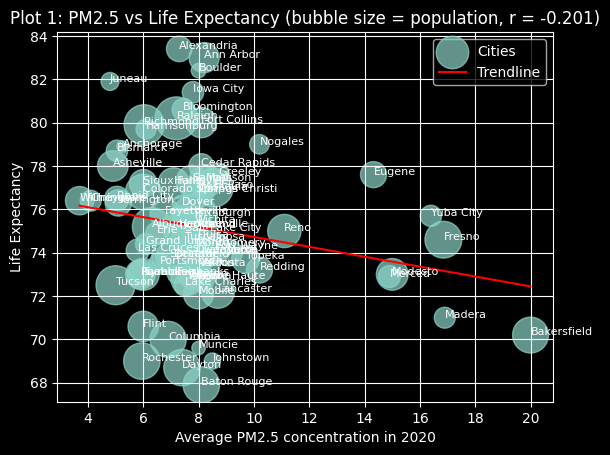

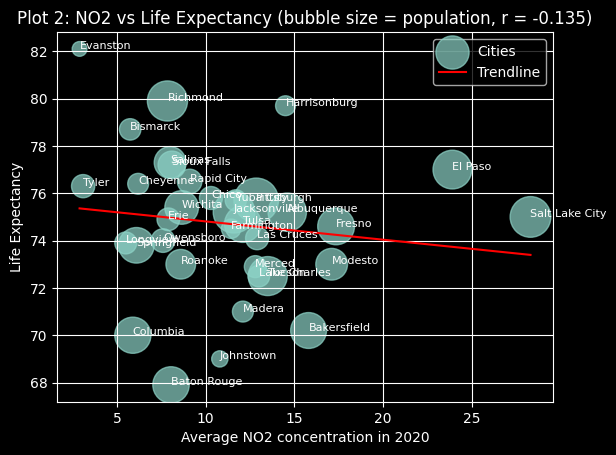

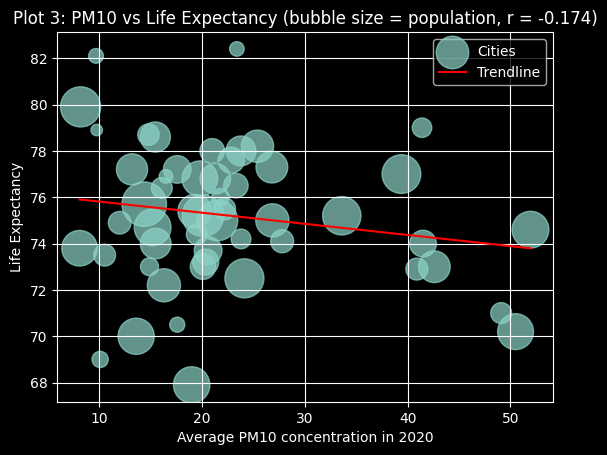

In [9]:
# Plot 1 PM 2.5 against Life Expectancy
plot_df_1=analysis_df[["pm25_mean","life_expectancy","population","city_clean"]].dropna().copy()

x1=plot_df_1["pm25_mean"]
y1=plot_df_1["life_expectancy"]
r1=pearson_r(x1,y1)
sizes1=np.sqrt(plot_df_1["population"])/np.sqrt(plot_df_1["population"]).max()*1000+30

plt.figure()
plt.scatter(x1,y1,s=sizes1,alpha=0.7,label="Cities")
add_trendline(x1,y1)
annotate_all_points(plot_df_1,"pm25_mean","life_expectancy","city_clean")

plt.title(f"Plot 1: PM2.5 vs Life Expectancy (bubble size = population, r = {r1:.3f})")
plt.xlabel("Average PM2.5 concentration in 2020")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()

plt.savefig("plot1_pm25_vs_life_expectancy.png")
plt.show()

# Plot 2 NO2 against Life Expectancy
plot_df_2=analysis_df[["no2_mean","life_expectancy","population","city_clean"]].dropna().copy()

x2=plot_df_2["no2_mean"]
y2=plot_df_2["life_expectancy"]
r2=pearson_r(x2,y2)
sizes2=np.sqrt(plot_df_2["population"])/np.sqrt(plot_df_2["population"]).max()*1000+30

plt.figure()
plt.scatter(x2,y2,s=sizes2,alpha=0.7,label="Cities")
add_trendline(x2,y2)
annotate_all_points(plot_df_2,"no2_mean","life_expectancy","city_clean")

plt.title(f"Plot 2: NO2 vs Life Expectancy (bubble size = population, r = {r2:.3f})")
plt.xlabel("Average NO2 concentration in 2020")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()

plt.savefig("plot2_no2_vs_life_expectancy.png")
plt.show()

# Plot 3 PM 10 against Life Expectancy
plot_df_3=analysis_df[["pm10_mean","life_expectancy","population"]].dropna().copy()
x3=plot_df_3["pm10_mean"]
y3=plot_df_3["life_expectancy"]
r3=pearson_r(x3,y3)
sizes3=np.sqrt(plot_df_3["population"])/np.sqrt(plot_df_3["population"]).max()*1000+30
plt.figure()
plt.scatter(x3,y3,s=sizes3,alpha=0.7,label="Cities")
add_trendline(x3,y3)
plt.title(f"Plot 3: PM10 vs Life Expectancy (bubble size = population, r = {r3:.3f})")
plt.xlabel("Average PM10 concentration in 2020")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()
plt.savefig("plot3_pm10_vs_life_expectancy.png")
plt.show()

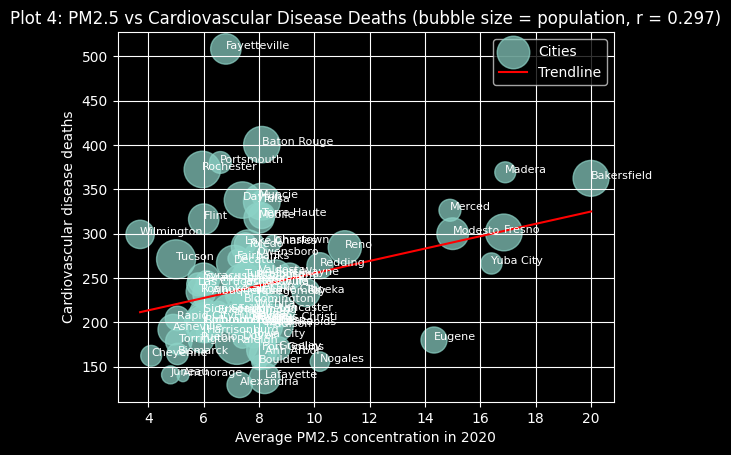

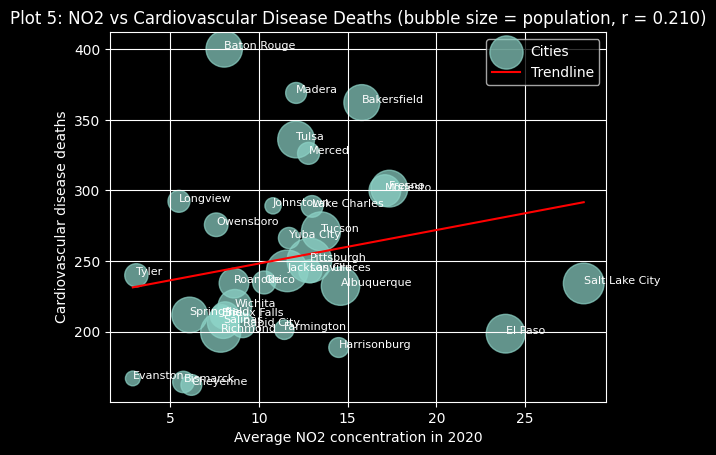

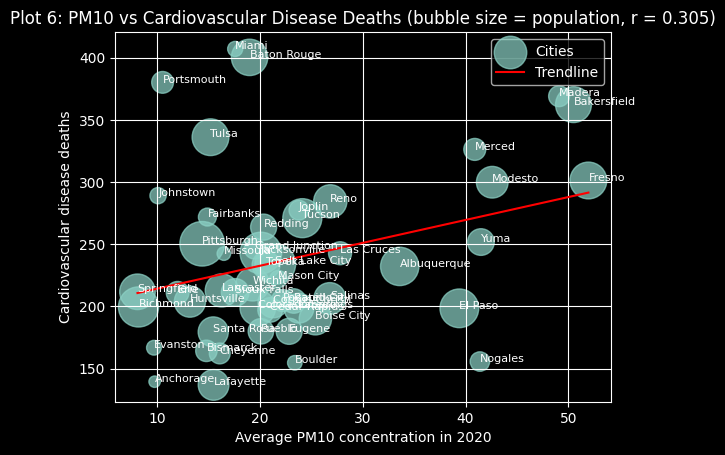

In [10]:
# Plot 4 pm2.5 vs death and cities are labeled
plot_df_4=analysis_df[["pm25_mean","cvd_deaths","population","city_clean"]].dropna().copy()
x4=plot_df_4["pm25_mean"]
y4=plot_df_4["cvd_deaths"]
r4=pearson_r(x4,y4)
sizes4=np.sqrt(plot_df_4["population"])/np.sqrt(plot_df_4["population"]).max()*1000+30
plt.figure()
plt.scatter(x4,y4,s=sizes4,alpha=0.7,label="Cities")
add_trendline(x4,y4)
annotate_all_points(plot_df_4,"pm25_mean","cvd_deaths","city_clean")
plt.title(f"Plot 4: PM2.5 vs Cardiovascular Disease Deaths (bubble size = population, r = {r4:.3f})")
plt.xlabel("Average PM2.5 concentration in 2020")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot4_pm25_vs_cvd_deaths.png")
plt.show()

# Plot 5 no2 vs death and cities are labeled
plot_df_5=analysis_df[["no2_mean","cvd_deaths","population","city_clean"]].dropna().copy()
x5=plot_df_5["no2_mean"]
y5=plot_df_5["cvd_deaths"]
r5=pearson_r(x5,y5)
sizes5=np.sqrt(plot_df_5["population"])/np.sqrt(plot_df_5["population"]).max()*1000+30
plt.figure()
plt.scatter(x5,y5,s=sizes5,alpha=0.7,label="Cities")
add_trendline(x5,y5)
annotate_all_points(plot_df_5,"no2_mean","cvd_deaths","city_clean")
plt.title(f"Plot 5: NO2 vs Cardiovascular Disease Deaths (bubble size = population, r = {r5:.3f})")
plt.xlabel("Average NO2 concentration in 2020")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot5_no2_vs_cvd_deaths.png")
plt.show()

# Plot 6 pm10 vs death and cities are labeled
plot_df_6=analysis_df[["pm10_mean","cvd_deaths","population","city_clean"]].dropna().copy()
x6=plot_df_6[("pm10_mean")]
y6=plot_df_6["cvd_deaths"]
r6=pearson_r(x6,y6)
sizes6=np.sqrt(plot_df_6["population"])/np.sqrt(plot_df_6["population"]).max()*1000+30
plt.figure()
plt.scatter(x6,y6,s=sizes6,alpha=0.7,label="Cities")
add_trendline(x6,y6)
annotate_all_points(plot_df_6,"pm10_mean","cvd_deaths","city_clean")
plt.title(f"Plot 6: PM10 vs Cardiovascular Disease Deaths (bubble size = population, r = {r6:.3f})")
plt.xlabel("Average PM10 concentration in 2020")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot6_pm10_vs_cvd_deaths.png")
plt.show()

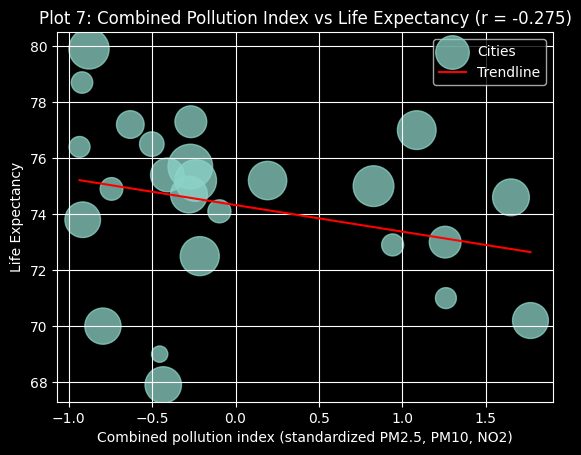

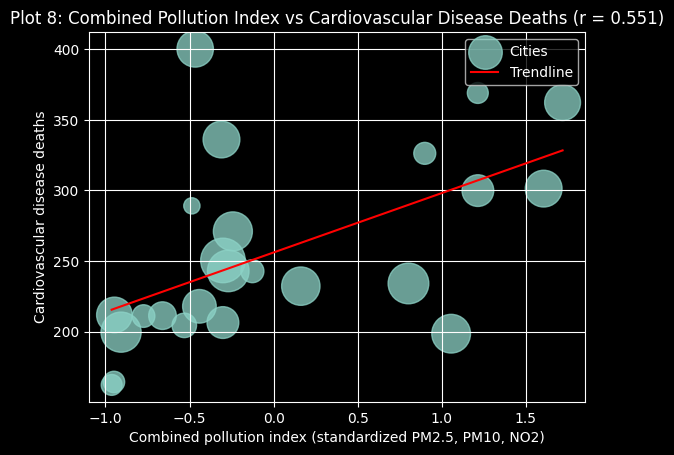

In [11]:
# Plot 7 combined relative pollution index vs life expectancy
plot_df_7=analysis_df[["pm25_mean","pm10_mean","no2_mean","life_expectancy","population"]].dropna().copy()
plot_df_7["pm25_z"]=zscore_series(plot_df_7["pm25_mean"])
plot_df_7["pm10_z"]=zscore_series(plot_df_7["pm10_mean"])
plot_df_7["no2_z"]=zscore_series(plot_df_7["no2_mean"])
plot_df_7["pollution_index"]=(plot_df_7["pm25_z"]+plot_df_7["pm10_z"]+plot_df_7["no2_z"])/3
x7=plot_df_7["pollution_index"]
y7=plot_df_7["life_expectancy"]
r7=pearson_r(x7,y7)
sizes7=np.sqrt(plot_df_7["population"])/np.sqrt(plot_df_7["population"]).max()*1000+30
plt.figure()
plt.scatter(x7,y7,s=sizes7,alpha=0.75,label="Cities")
add_trendline(x7,y7)
plt.title(f"Plot 7: Combined Pollution Index vs Life Expectancy (r = {r7:.3f})")
plt.xlabel("Combined pollution index (standardized PM2.5, PM10, NO2)")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()
plt.savefig("plot7_pollution_index_vs_life_expectancy.png")
plt.show()

# Plot 8 combined pollution index vs cardiovascular disease death
plot_df_8=analysis_df[["pm25_mean","pm10_mean","no2_mean","cvd_deaths","population"]].dropna().copy()
plot_df_8["pm25_z"]=zscore_series(plot_df_8["pm25_mean"])
plot_df_8["pm10_z"]=zscore_series(plot_df_8["pm10_mean"])
plot_df_8["no2_z"]=zscore_series(plot_df_8["no2_mean"])
plot_df_8["pollution_index"]=(plot_df_8["pm25_z"]+plot_df_8["pm10_z"]+plot_df_8["no2_z"])/3
x8=plot_df_8["pollution_index"]
y8=plot_df_8["cvd_deaths"]
r8=pearson_r(x8,y8)
sizes8=np.sqrt(plot_df_8["population"])/np.sqrt(plot_df_8["population"]).max()*1000+30
plt.figure()
plt.scatter(x8,y8,s=sizes8,alpha=0.75,label="Cities")
add_trendline(x8,y8)
plt.title(f"Plot 8: Combined Pollution Index vs Cardiovascular Disease Deaths (r = {r8:.3f})")
plt.xlabel("Combined pollution index (standardized PM2.5, PM10, NO2)")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot8_pollution_index_vs_cvd_deaths.png")
plt.show()

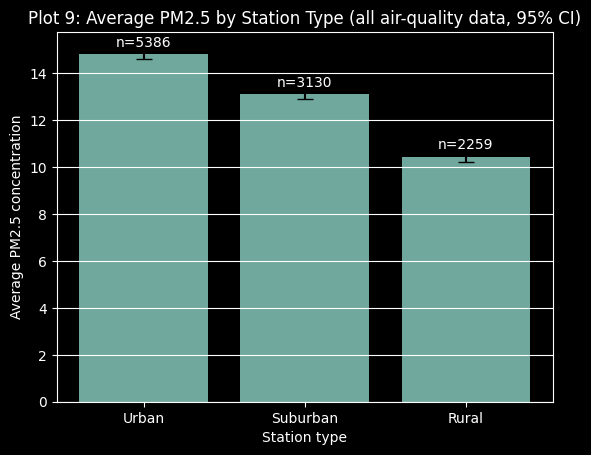

In [14]:
# Plot 9
plot_df_9=main_raw.copy()
plot_df_9["station_group"]=plot_df_9["type_of_stations"].apply(station_group)
plot_df_9=plot_df_9[plot_df_9["station_group"].isin(["Urban","Suburban","Rural"])].copy()
plot_df_9=plot_df_9[["station_group","pm25_concentration"]].dropna()
station_pm25=summarize_with_ci(plot_df_9,group_col="station_group",value_col="pm25_concentration",order=["Urban","Suburban","Rural"])
plt.figure()
bars9=plt.bar(station_pm25["station_group"],station_pm25["mean"],yerr=station_pm25["ci95"],capsize=6,alpha=0.8)
for bar,n in zip(bars9,station_pm25["count"]):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.2,f"n={int(n)}",ha="center",va="bottom")
plt.title("Plot 9: Average PM2.5 by Station Type (all air-quality data, 95% CI)")
plt.xlabel("Station type")
plt.ylabel("Average PM2.5 concentration")
plt.grid(axis="y")
plt.savefig("plot9_pm25_by_station_type.png")
plt.show()

## Result Interpretation

In [ ]:
print("\nMain correlations (merged dataset focus):")
print(f"PM2.5 vs Life Expectancy: {r1:.3f}")
print(f"PM2.5 vs CVD Deaths: {r2:.3f}")
print(f"NO2 vs Life Expectancy: {r3:.3f}")
print(f"log10(Population) vs CVD Deaths: {r4:.3f}")
print(f"PM10 vs Life Expectancy: {r5:.3f}")
print(f"Life Expectancy vs CVD Deaths: {r6:.3f}")
print(f"PM2.5 vs NO2: {r7:.3f}")
print(f"Combined Pollution Index vs Life Expectancy: {r13:.3f}")
print(f"Combined Pollution Index vs CVD Deaths: {r14:.3f}")
print(f"Matched cities in merged dataset: {analysis_df['city_clean'].nunique()}")
print("\nStation type counts in merged US dataset from original 2020 field:")
print(analysis_df["station_group"].value_counts(dropna=False))
print("\nStation type counts used in plot 8:")
print(station_pm25[["station_group","count"]])

## References
- World Health Organization (2024) _WHO Ambient Air Quality Database (Update Jan 2024)_. Available at: https://www.who.int/publications/m/item/who-ambient-air-quality-database-(update-jan-2024). [Accessed 27 March 2026]
- Department of Population Health, NYU Langone Health (2026) _City Health Dashboard_. Available at: https://www.cityhealthdashboard.com/data-access. [Accessed 27 March 2026]